# Preprocessing IBL Behavioral Sessions   
This notebook preprocesses trial-level behavioral data from the International Brain Laboratory visual decision-making task. It identifies eligible consecutive session pairs, constructs trial- and session-level variables, calculates previous-session biased exposure, and exports the datasets used in the subsequent analyses.


## 1. Setup and imports

In [63]:
# Imports

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [64]:
# Define helper functions for plotting
def summarize_session_metric(df, metric_name, compute):
    """
    Build a per-session summary table for a given metric.

    Parameters
    ----------
    df : DataFrame
        Trial-level dataframe indexed by session.
    metric_name : str
        Name of the metric column to create.
    compute : callable
        Function taking a session-level DataFrame and returning the metric value.

    Returns
    -------
    DataFrame
        One row per session with columns ['session', 'training_status', metric_name].
    """
    rows = []
    for session_id, session_df in df.groupby(level='session'):
        rows.append({
            'session': session_id,
            'training_status': session_df['training_status'].iloc[0],
            metric_name: compute(session_df),
        })
    return pd.DataFrame(rows)


def interactive_session_hist(summary_df, metric_name,
                             xlabel, title_base,
                             bins=30, integer_bins=False):
    """
    Create an interactive histogram for a session-level metric.

    Parameters
    ----------
    summary_df : DataFrame
        Output of summarize_session_metric.
    metric_name : str
        Column in summary_df to plot.
    xlabel : str
        Label for the x-axis.
    title_base : str
        Base title for the plot.
    bins : int
        Number of bins for continuous histograms.
    integer_bins : bool
        If True, use integer-aligned bins for discrete counts.
    """
    statuses = ['ready4ephysrig', 'ready4delay', 'ready4recording']

    def plot_hist(selection):
        if selection == 'Combined (all three)':
            data = summary_df[metric_name]
            label = 'all three statuses'
        else:
            data = summary_df.loc[
                summary_df['training_status'] == selection, metric_name]
            label = selection

        plt.figure(figsize=(12, 5))

        if len(data) == 0:
            plt.title(f'No sessions for {label}')
            plt.show()
            return

        if integer_bins:
            maxval = int(data.max())
            plt.hist(data, bins=range(0, maxval + 2),
                     edgecolor='black', align='left')
            plt.xticks(range(0, maxval + 1))
        else:
            plt.hist(data, bins=bins, edgecolor='black')

        plt.axvline(data.median(), color='red', linestyle='--',
                    label=f'median = {data.median():.0f}')
        plt.xlabel(xlabel)
        plt.ylabel('Number of sessions')
        plt.title(f'{title_base} — {label}  (n={len(data)} sessions)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(data.describe())

    dropdown = widgets.Dropdown(
        options=['Combined (all three)'] + statuses,
        value='Combined (all three)',
        description='View:',
        style={'description_width': 'initial'},
    )
    widgets.interact(plot_hist, selection=dropdown)

In [65]:
# Path to the combined trial-level dataset generated by the loading pipeline

DATA_PATH = Path("all_trials.pqt")

if not DATA_PATH.exists():
    raise FileNotFoundError( f"Input file not found: {DATA_PATH.resolve()}\n"
        "Run the data-loading notebook before running preprocessing.")

all_trials = pd.read_parquet(DATA_PATH)

if all_trials.index.name != "session":
    raise ValueError("Expected session IDs to be stored in an index named 'session'.")

print(f"Loaded {len(all_trials):,} rows and " f"{all_trials.shape[1]:,} columns.")

print(f"Index name: {all_trials.index.name}")

column_overview = pd.DataFrame({ "column": all_trials.columns,
        "dtype": all_trials.dtypes.astype(str).values,
        "missing_n": all_trials.isna().sum().values,})

display(column_overview)
display(all_trials.head())

Loaded 5,532,606 rows and 33 columns.
Index name: session


,column,dtype,missing_n
0,intervals_0,float64,0
1,intervals_1,float64,0
2,goCue_times,float64,159412
3,response_times,float64,0
4,choice,float64,0
5,stimOn_times,float64,1821311
6,contrastLeft,float64,2766180
7,contrastRight,float64,2766426
8,feedback_times,float64,17928
9,feedbackType,float64,0


,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,...,session_start_time,training_status,lab,subject,number,task_protocol,projects,performance_easy,training_day,session_number
session,,,,,,,,,,,,,,,,,,,,,
b117ed10-6871-42b3-9193-ca708dac4353,0.0000,89.642702,6.9477,12.0563,1.0,6.9297,1.0,NaN,12.0563,1.0,...,2019-11-04 09:29:50.380830,in training,churchlandlab,CSHL045,1,_iblrig_tasks_trainingChoiceWorld6.0.6,ibl_neuropixel_brainwide_01,0.524823,0.0,NaN
b117ed10-6871-42b3-9193-ca708dac4353,90.2706,100.694903,90.8707,99.1949,1.0,90.8403,1.0,NaN,99.1949,1.0,...,2019-11-04 09:29:50.380830,in training,churchlandlab,CSHL045,1,_iblrig_tasks_trainingChoiceWorld6.0.6,ibl_neuropixel_brainwide_01,0.524823,0.0,NaN
b117ed10-6871-42b3-9193-ca708dac4353,101.6900,109.067302,102.2129,107.5673,-1.0,102.1760,NaN,0.5,107.5673,1.0,...,2019-11-04 09:29:50.380830,in training,churchlandlab,CSHL045,1,_iblrig_tasks_trainingChoiceWorld6.0.6,ibl_neuropixel_brainwide_01,0.524823,0.0,NaN
b117ed10-6871-42b3-9193-ca708dac4353,109.5048,121.653802,116.0801,119.1538,1.0,116.0465,NaN,1.0,119.1865,-1.0,...,2019-11-04 09:29:50.380830,in training,churchlandlab,CSHL045,1,_iblrig_tasks_trainingChoiceWorld6.0.6,ibl_neuropixel_brainwide_01,0.524823,0.0,NaN
b117ed10-6871-42b3-9193-ca708dac4353,122.2313,129.362803,125.2503,127.8628,1.0,125.2174,1.0,NaN,127.8628,1.0,...,2019-11-04 09:29:50.380830,in training,churchlandlab,CSHL045,1,_iblrig_tasks_trainingChoiceWorld6.0.6,ibl_neuropixel_brainwide_01,0.524823,0.0,NaN


## 2. Initial data validation   
Before applying the inclusion criteria, we inspect the size, missingness, and numerical ranges of the variables required by the preprocessing pipeline.
We first summarize the size of the combined dataset and examine how mice, sessions, and trials are distributed across training stages.



In [66]:
# Summarise the size and temporal coverage of the dataset

session_start_times = pd.to_datetime(all_trials["session_start_time"],errors="coerce")

dataset_overview = pd.Series(
    {
        "Trials": len(all_trials),
        "Columns": all_trials.shape[1],
        "Sessions": all_trials.index.nunique(),
        "Mice": all_trials["subject"].nunique(),
        "First session": session_start_times.min(),
        "Last session": session_start_times.max(),
    },
    name="Value").to_frame()

display(dataset_overview)

,Value
Trials,5532606
Columns,33
Sessions,8135
Mice,140
First session,2018-12-17 16:17:51
Last session,2020-12-06 15:48:51.149375


In [67]:
# Summarise the amount of data available at each training stage

training_status_overview = (all_trials
    .reset_index()
    .groupby("training_status", dropna=False)
    .agg(mice=("subject", "nunique"),
        sessions=("session", "nunique"),
        trials=("session", "size"),)
    .sort_values("mice", ascending=False))

display(training_status_overview)

print("Note: mouse counts overlap across training statuses because the same mouse may progress through several stages.")

,mice,sessions,trials
training_status,,,
in training,139,2376,1382935
trained 1b,133,1745,1285322
ready4ephysrig,114,1828,1375991
trained 1a,114,810,541835
ready4delay,82,920,630788
ready4recording,26,212,135467
untrainable,12,112,81777
unbiasable,6,123,94934
NaN,5,9,3557


Note: mouse counts overlap across training statuses because the same mouse may progress through several stages.


## 3. Extract the analysis cohort

To restrict the analysis to mice with stable, well-trained task performance, we first identified animals that eventually reached the `ready4recording` stage. Reaching this stage indicates that a mouse successfully progressed through the IBL training pipeline and was considered suitable for experimental recording. This produced a cohort of 26 mice.

For these mice, we retained sessions labelled `ready4ephysrig`, `ready4delay`, or `ready4recording`. These three statuses represent later, task-ready stages of training. Retaining all three stages increases the number of usable sessions while excluding earlier training periods, during which behaviour and sensitivity to the task structure may still have been changing.

We then restricted the data to the `biasedChoiceWorld` and `ephysChoiceWorld` task families. Both protocols use the relevant visual decision-making structure, including an initial unbiased block followed by alternating left- and right-biased blocks. Although `ephysChoiceWorld` was designed for electrophysiological experiments, these sessions remain appropriate because the present study analyses only behavioural variables. The required block structure is verified explicitly in the subsequent preprocessing steps.

In [68]:
# Define the training stages and task protocols used in the analysis

READY_STATUSES = ["ready4ephysrig", "ready4delay","ready4recording"]

TASK_PATTERN = r"biasedChoiceWorld|ephysChoiceWorld"

# Identify mice that eventually reached the fully trained stage
recording_ready_subjects = (all_trials.loc[all_trials["training_status"] == "ready4recording","subject"].dropna().unique())

# Retain ready-stage sessions from those mice in the relevant task protocols
candidate_trials = all_trials.loc[
    all_trials["subject"].isin(recording_ready_subjects)
    & all_trials["training_status"].isin(READY_STATUSES)
    & all_trials["task_protocol"].str.contains(TASK_PATTERN,case=False, na=False)].copy()

cohort_summary = pd.Series(
    {
        "Mice reaching ready4recording": len(recording_ready_subjects),
        "Mice retained after all filters": candidate_trials["subject"].nunique(),
        "Sessions retained": candidate_trials.index.nunique(),
        "Trials retained": len(candidate_trials),
    }, name="Count").to_frame()

display(cohort_summary)

,Count
Mice reaching ready4recording,26
Mice retained after all filters,26
Sessions retained,611
Trials retained,467165


## 4. Add trial-level variables

The following cells add variables describing each trial’s position within the session and its stimulus information. Trials are assigned a block number, an overall trial number, and a trial number within the current block. Signed contrast and nominal stimulus side are then constructed for use in the later analyses.

In [69]:
# Add block and trial numbering to the candidate sessions

def label_blocks(session_df):
    """Sort chronologically, label contiguous probabilityLeft runs as blocks,
    and number trials."""
    s = session_df.sort_values('intervals_0').copy()
    s['block']          = s['probabilityLeft'].ne(s['probabilityLeft'].shift()).cumsum()
    s['trial_number']   = np.arange(1, len(s) + 1)              # position in session
    s['trial_in_block'] = s.groupby('block').cumcount() + 1     # position within its block
    return s

pieces = []
for session_id, session_df in candidate_trials.groupby(level='session'):
    pieces.append(label_blocks(session_df))
candidate_trials_all = pd.concat(pieces)

# Check trial numbering within the initial block
b1 = candidate_trials_all[candidate_trials_all['block'] == 1]
print(f"block 1 trials: {len(b1)}  ({b1.index.nunique()} sessions × 90 = {b1.index.nunique()*90})")
print(f"trial_number range in block 1: {b1['trial_number'].min()}–{b1['trial_number'].max()}")
print(f"trial_number == trial_in_block in block 1: {(b1['trial_number'] == b1['trial_in_block']).all()}")

block 1 trials: 54649  (611 sessions × 90 = 54990)
trial_number range in block 1: 1–90
trial_number == trial_in_block in block 1: True


In [70]:
# Add signed contrast: positive for left stimuli and negative for right stimuli
# Add stim_side to retain the nominal left/right side, including for zero-contrast trials

# verify the premise first
both    = candidate_trials_all['contrastLeft'].notna() & candidate_trials_all['contrastRight'].notna()
neither = candidate_trials_all['contrastLeft'].isna()  & candidate_trials_all['contrastRight'].isna()
print(f"both: {both.sum()}   neither: {neither.sum()}")    # must be 0, 0

# signed contrast: left positive, right negative
candidate_trials_all['contrast_all'] = np.where(
    candidate_trials_all['contrastLeft'].notna(),
     candidate_trials_all['contrastLeft'],
    -candidate_trials_all['contrastRight']
) + 0.0

# nominal side: 1 = left, -1 = right
candidate_trials_all['stim_side'] = np.where(candidate_trials_all['contrastLeft'].notna(), 1, -1)

print(candidate_trials_all['contrast_all'].value_counts().sort_index())
print(candidate_trials_all.loc[candidate_trials_all['contrast_all'] == 0, 'stim_side'].value_counts())

both: 0   neither: 0
contrast_all
-1.0000    48238
-0.2500    46572
-0.1250    47195
-0.0625    47074
 0.0000    87551
 0.0625    47349
 0.1250    47374
 0.2500    47949
 1.0000    47863
Name: count, dtype: int64
stim_side
-1    44100
 1    43451
Name: count, dtype: int64


## 5. Define the session \(n\) and session \(n+1\) pools

The analysis examines pairs of consecutive behavioral sessions. Session \(n\) is the preceding session and provides the biased-block exposure variables, while session \(n+1\) is the subsequent session and provides the choices measured during its initial unbiased block.

Because the two sessions serve different roles, they have different eligibility criteria. Session \(n+1\) requires a valid initial unbiased block. Session \(n\) must also contain sufficient biased-block exposure for the previous-session predictors to be calculated reliably.

No-response trials are retained while constructing both pools so that trial numbers, block lengths, and exposure measures reflect the complete sequence of presented trials. They are removed later when preparing the data for choice analyses.

### 5.1. Define the session \(n+1\) pool

Session \(n+1\) provides the choices examined during the initial unbiased block. An eligible session must begin with exactly 90 trials in which `probabilityLeft = 0.5`, followed by a trial with a biased stimulus probability at trial 91.

These criteria verify that the session follows the standard task structure and that its initial unbiased block contains exactly 90 trials.

In [71]:
# Create the n+1 sessions pool

valid_ids = []
opening_lengths = []
excluded_sessions = []

for session_id, session_df in candidate_trials_all.groupby(level='session'):
    session_df = session_df.sort_values('intervals_0')

    pl = session_df['probabilityLeft'].to_numpy()
    unbiased = np.isclose(pl, 0.5)
    opening_len = np.argmax(~unbiased) if (~unbiased).any() else len(pl)
    opening_lengths.append(opening_len)

    protocols = session_df['task_protocol'].unique()
    if len(protocols) != 1:
        raise ValueError(f"More than one protocol found in session {session_id}")
    protocol = protocols[0]

    exclude_reason = None

    if len(session_df) < 91:
        exclude_reason = 'fewer_than_91_trials'
    elif not unbiased[:90].all():
        exclude_reason = 'not_all_first_90_are_0.5'
    elif unbiased[90]:
        exclude_reason = 'trial_91_is_still_0.5_opening_block_longer_than_90'
    else:
        valid_ids.append(session_id)

    if exclude_reason is not None:
        excluded_sessions.append({
            'session': session_id,
            'n_trials': len(session_df),
            'opening_unbiased_len': opening_len,
            'exclude_reason': exclude_reason,
            'protocol': protocol,
            'stage': session_df['training_status'].unique()[0]
        })

# Set of eligible n+1 sessions
n1_pool = candidate_trials_all[candidate_trials_all.index.isin(valid_ids)].copy()

print(f"Sessions before: {candidate_trials_all.index.nunique()}")
print(f"Sessions after:  {n1_pool.index.nunique()}")
print(f"Trials after:    {len(n1_pool)}")

print("Opening unbiased run length:")
print(pd.Series(opening_lengths).value_counts().sort_index().head(10))

Sessions before: 611
Sessions after:  602
Trials after:    464432
Opening unbiased run length:
0       2
14      1
33      1
44      1
68      1
79      1
89      2
90    602
Name: count, dtype: int64


In [72]:
# Inspect excluded sessions

excluded_sessions_df = pd.DataFrame(excluded_sessions)

excluded_trials_df = candidate_trials_all[~candidate_trials_all.index.isin(valid_ids)].copy()

print("\nExcluded sessions summary:")
display(excluded_sessions_df.sort_values(['exclude_reason', 'opening_unbiased_len']))

print("\nExcluded trials dataframe preview:")
display(excluded_trials_df[
    ['subject', 'probabilityLeft', 'block', 'trial_number', 'trial_in_block']
].head(10))


Excluded sessions summary:


,session,n_trials,opening_unbiased_len,exclude_reason,protocol,stage
6,9d6ebbc5-93b4-409f-85ea-1fd44a96c4db,14,14,fewer_than_91_trials,_iblrig_tasks_biasedChoiceWorld6.4.0,ready4recording
3,3bb8777d-3ad0-496f-bc2c-6b2664442648,33,33,fewer_than_91_trials,_iblrig_tasks_biasedChoiceWorld6.4.0,ready4recording
2,0f9305b0-24b8-4d8c-a998-0d841668b666,44,44,fewer_than_91_trials,_iblrig_tasks_biasedChoiceWorld6.4.1,ready4delay
8,e371d646-e287-4183-aa6a-76abe0838841,68,68,fewer_than_91_trials,_iblrig_tasks_biasedChoiceWorld5.2.9,ready4ephysrig
1,08e25a6c-4223-462a-a856-a3a587146668,79,79,fewer_than_91_trials,_iblrig_tasks_ephysChoiceWorld6.2.5,ready4recording
0,05d5fc29-19b5-40e1-b484-0b2040148bde,578,0,not_all_first_90_are_0.5,_bandit_shaping_90_10_biasedChoiceWorld6.4.2,ready4recording
4,3f03d368-cb50-40b6-8af2-b08b384d9a0b,877,0,not_all_first_90_are_0.5,_bandit_shaping_biasedChoiceWorld6.4.2,ready4recording
5,6364ff7f-6471-415a-ab9e-632a12052690,628,89,not_all_first_90_are_0.5,_iblrig_tasks_ephysChoiceWorld6.4.0,ready4recording
7,dd4da095-4a99-4bf3-9727-f735077dba66,412,89,not_all_first_90_are_0.5,_iblrig_tasks_ephysChoiceWorld6.1.3,ready4recording



Excluded trials dataframe preview:


,subject,probabilityLeft,block,trial_number,trial_in_block
session,,,,,
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,1,1
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,2,2
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,3,3
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,4,4
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,5,5
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,6,6
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,7,7
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,8,8
05d5fc29-19b5-40e1-b484-0b2040148bde,ibl_witten_12,0.1,1,9,9


In [73]:
# Check the trials spread for n1_pool dataset
n1_biased_table = summarize_session_metric(n1_pool, 'n_biased',lambda s: (s['block'] != 1).sum())

interactive_session_hist(
    n1_biased_table, 'n_biased',
    xlabel='Number of biased trials per session',
    title_base='Biased-trial counts per eligible n+1 session'
)

interactive(children=(Dropdown(description='View:', options=('Combined (all three)', 'ready4ephysrig', 'ready4…

### 5.2. Define the session \(n\) pool

Session \(n\) provides the preceding biased-block exposure used to predict choices in session \(n+1\). It must therefore satisfy the valid 90-trial opening-block criterion used for the \(n+1\) pool and contain sufficient subsequent biased-task structure.

In the IBL task, biased blocks are designed to contain between 20 and 100 trials. A terminal block containing fewer than 20 trials therefore indicates that the session ended before the block was completed. We exclude these sessions because the mouse received only a truncated final exposure, which may not be comparable to exposure from a complete biased block and may provide insufficient time for the animal’s subjective prior to adapt to the terminal block.

Eligible sessions must also contain at least two biased blocks. This ensures that the previous-session exposure measure is based on more than a single biased block and includes experience with the alternating block structure.

In [74]:
# n-pool built on n1_pool: terminal block >= 20 trials, and >= 2 biased blocks

records = []
for session_id, s in n1_pool.groupby(level='session'):
    biased   = s[s['block'] != 1]
    terminal = s[s['block'] == s['block'].max()]

    records.append({
        'session':            session_id,
        'subject':            s['subject'].iloc[0],
        'session_start_time': s['session_start_time'].iloc[0],
        'training_status':    s['training_status'].iloc[0],
        'n_total':            len(s),
        'n_biased':           len(biased),
        'n_biased_blocks':    biased['block'].nunique(),
        'terminal_len':       len(terminal),
        'terminal_prob':      terminal['probabilityLeft'].iloc[0],
    })

n1_summary = pd.DataFrame(records)
print(f"n+1 pool sessions: {len(n1_summary)}")

#terminal block >= 20 trials
c2 = n1_summary[n1_summary['terminal_len'] >= 20]
print(f"terminal >= 20:      {len(c2)}  (removed {len(n1_summary)-len(c2)})")

#>= 2 biased blocks
c3 = c2[c2['n_biased_blocks'] >= 2]
print(f">= 2 biased blocks:  {len(c3)}  (removed {len(c2)-len(c3)})")

n_summary = c3.copy()

valid_terminal = (
    np.isclose(n_summary['terminal_prob'], 0.2)
    | np.isclose(n_summary['terminal_prob'], 0.8)
)

if not valid_terminal.all():
    raise ValueError("Unexpected terminal probability found in the n-session pool.")

n_summary['terminal_side'] = np.where(np.isclose(n_summary['terminal_prob'], 0.8), 1, -1)

n_pool = n1_pool[n1_pool.index.isin(set(n_summary['session']))].copy()

print(f"\n=== n POOL ===")
print(f"Sessions: {n_pool.index.nunique()}")
print(f"Trials:   {len(n_pool)}")
print(f"Subjects: {n_pool['subject'].nunique()}")

n+1 pool sessions: 602
terminal >= 20:      377  (removed 225)
>= 2 biased blocks:  376  (removed 1)

=== n POOL ===
Sessions: 376
Trials:   298273
Subjects: 26


In [75]:
# Check the trials spread for n_pool dataset

n_biased_table = summarize_session_metric(n_pool, 'n_biased',lambda s: (s['block'] != 1).sum())

interactive_session_hist(
    n_biased_table, 'n_biased',
    xlabel='Number of biased trials per session',
    title_base='Biased-trial counts per eligible n session'
)

interactive(children=(Dropdown(description='View:', options=('Combined (all three)', 'ready4ephysrig', 'ready4…

In [76]:
#check the biased BLOCK count spread for n_pool dataset

n_biased_blocks_table = summarize_session_metric(n_pool, 'n_biased_blocks',lambda s: s.loc[s['block'] != 1, 'block'].nunique())

interactive_session_hist(
    n_biased_blocks_table, 'n_biased_blocks',
    xlabel='Number of biased blocks per session',
    title_base='Biased-block counts per eligible n session',
    integer_bins=True
)

interactive(children=(Dropdown(description='View:', options=('Combined (all three)', 'ready4ephysrig', 'ready4…

subject
ibl_witten_12    47
ZM_1745          33
DY_010           25
DY_011           25
SWC_014          17
ZM_2241          17
ZM_1897          17
ZM_2240          16
ZM_2107          15
CSHL049          14
CSHL058          14
CSHL053          13
ibl_witten_19    13
CSHL046          13
DY_009           11
ZM_1898          10
CSHL045          10
NYU-12           10
DY_008           10
ibl_witten_17     9
CSHL060           9
ZM_2245           8
ibl_witten_20     6
NYU-09            5
DY_013            5
ZM_3003           4
Name: session, dtype: int64

Mice: 26
Median: 13  |  Min: 4  |  Max: 47


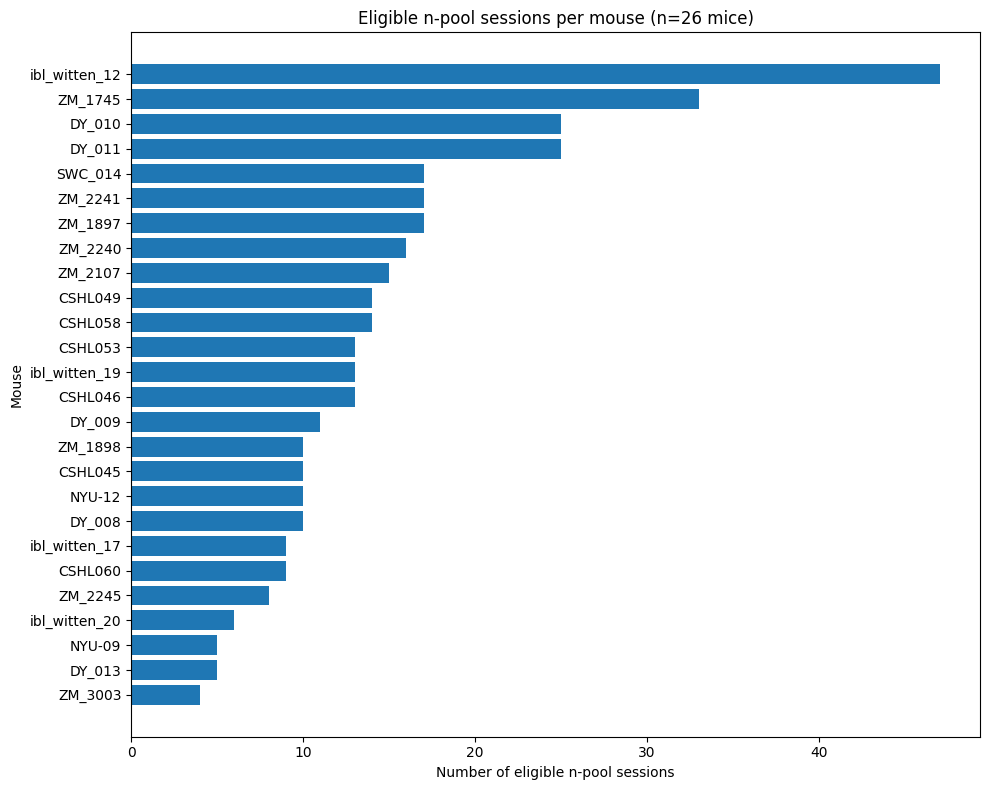

In [77]:
# Number of eligible n-pool sessions contributed by each mouse

sessions_per_mouse = (
    n_summary.groupby('subject')['session']
    .count()
    .sort_values(ascending=False)
)

print(sessions_per_mouse)
print(f"\nMice: {len(sessions_per_mouse)}")
print(f"Median: {sessions_per_mouse.median():.0f}  |  "
      f"Min: {sessions_per_mouse.min()}  |  Max: {sessions_per_mouse.max()}")

plt.figure(figsize=(10, 8))
plt.barh(sessions_per_mouse.index, sessions_per_mouse.values)
plt.xlabel('Number of eligible n-pool sessions')
plt.ylabel('Mouse')
plt.title(f'Eligible n-pool sessions per mouse (n={len(sessions_per_mouse)} mice)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Construct consecutive session pairs

The session pools define which sessions are eligible to serve as \(n\) and \(n+1\), but they do not establish whether two eligible sessions actually occurred consecutively. We therefore construct a pair table in which each row represents one session transition for the same mouse:

- `session_n` is eligible for the session \(n\) pool and provides the preceding biased-block exposure.
- `session_n1` is the mouse’s immediately following session and is eligible for the session \(n+1\) pool.

Consecutiveness is determined using each mouse’s complete chronological session history rather than only the filtered \(n\) and \(n+1\) pools. This prevents two eligible sessions from being incorrectly paired when an ineligible session occurred between them.

For each valid pair, the inter-session interval is calculated from the estimated end of session \(n\) to the start of session \(n+1\). One anomalously short transition is excluded using a minimum gap of 12 hours. No upper gap limit is applied, allowing the remaining range of inter-session timescales to be examined in later analyses.

In [78]:
# adjacency judged over each mouse's complete session history (all_trials, 26 mice),
# so any intervening session — of any protocol or training status — blocks a pair

mice = all_trials[all_trials['subject'].isin(recording_ready_subjects)]

# Session duration from intervals_0 (last trial's START), not intervals_1 (last trial's END).
# Reason: one session (c187e864-...) has a corrupt intervals_1 value of 6.8e12 s (~216,000 yr),
# which overflows the timedelta conversion. That session's intervals_0 is clean (0–3193 s,
# 848 trials, block 1 = 90), so trial ordering and all analysis using it were unaffected —
# only the end-time column is bad. Using intervals_0 sidesteps the corrupt column entirely.
# Cost: duration undercounts by approximately one trial (~4 s), negligible relative to the multi-hour inter-session gaps.

sess_dur = mice.groupby(level='session')['intervals_0'].max().rename('dur_sec')

# guard anyway, in case another session has a bad intervals_0
n_bad = (~sess_dur.between(0, 86400)).sum()
if n_bad:
    print(f"WARNING: {n_bad} sessions with implausible duration — falling back to start-to-start")
sess_dur = sess_dur.where(sess_dur.between(0, 86400))

order = (mice.reset_index()
         .drop_duplicates('session')[['session', 'subject', 'session_start_time']]
         .assign(session_start_time=lambda d: pd.to_datetime(d['session_start_time']))
         .merge(sess_dur, on='session')
         # fillna(0) => bad-duration sessions fall back to start-to-start (gap overstated, not invented)
         .assign(session_end_time=lambda d: d['session_start_time']
                 + pd.to_timedelta(d['dur_sec'].fillna(0), unit='s'))
         .sort_values(['subject', 'session_start_time'])
         .reset_index(drop=True))

n_ids  = set(n_pool.index.unique())     # eligible as session n
n1_ids = set(n1_pool.index.unique())    # eligible as session n+1

print(f"adjacency frame: {order['session'].nunique()} sessions")
print(f"eligible as n:   {len(n_ids)}")
print(f"eligible as n+1: {len(n1_ids)}")
print(f"median session duration: {(order['dur_sec']/3600).median():.2f} h")

pairs = []
for subject, grp in order.groupby('subject'):
    grp = grp.reset_index(drop=True)
    for i in range(len(grp) - 1):
        s_n, s_n1 = grp.iloc[i], grp.iloc[i + 1]
        if s_n['session'] not in n_ids:
            continue
        if s_n1['session'] not in n1_ids:
            continue
        pairs.append({
            'subject':    subject,
            'session_n':  s_n['session'],
            'session_n1': s_n1['session'],
            # END of session n -> START of session n+1 (true elapsed rest between sessions)
            'gap_hours':  (s_n1['session_start_time'] - s_n['session_end_time']).total_seconds() / 3600,
        })

pair_table = pd.DataFrame(pairs)
pair_table['gap_days'] = pair_table['gap_hours'] / 24

print(f"\nRaw pairs: {len(pair_table)} from {pair_table['subject'].nunique()} mice")
print(pair_table['gap_hours'].describe())
print(f"negative gaps (overlapping sessions — should be 0): {(pair_table['gap_hours'] < 0).sum()}")
for lo, hi in [(12, 48), (12, 96), (12, 168)]:
    m = (pair_table['gap_hours'] >= lo) & (pair_table['gap_hours'] <= hi)
    print(f"  gap {lo}-{hi}h: {m.sum()} pairs, {pair_table[m]['subject'].nunique()} mice")

adjacency frame: 1469 sessions
eligible as n:   376
eligible as n+1: 602
median session duration: 1.14 h

Raw pairs: 360 from 26 mice
count     360.000000
mean       48.607019
std       131.752148
min         0.107769
25%        22.268791
50%        23.304513
75%        44.843230
max      2276.081768
Name: gap_hours, dtype: float64
negative gaps (overlapping sessions — should be 0): 0
  gap 12-48h: 275 pairs, 26 mice
  gap 12-96h: 340 pairs, 26 mice
  gap 12-168h: 349 pairs, 26 mice


In [79]:
# Exclude very short inter-session gaps
# One pair has a gap of approximately 6.5 minutes, which is consistent with
# an interrupted session followed by an immediate restart rather than a new session.

n_short = (pair_table['gap_hours'] < 12).sum()
print(f"Pairs with gap < 12 h: {n_short}")

n_before = len(pair_table)
pair_table = pair_table[pair_table['gap_hours'] >= 12].copy()

print(f"Pairs: {n_before} -> {len(pair_table)}  (removed {n_before - len(pair_table)})")
print(f"Gap range now: {pair_table['gap_hours'].min():.1f}–{pair_table['gap_hours'].max():.1f} h")

Pairs with gap < 12 h: 1
Pairs: 360 -> 359  (removed 1)
Gap range now: 14.1–2276.1 h


In [80]:
# Inspect the shortest remaining inter-session gaps after excluding gaps under 12 hours
print(pair_table.nsmallest(10, 'gap_hours')
      [['subject', 'gap_hours', 'session_n', 'session_n1']])

           subject  gap_hours                             session_n  \
333  ibl_witten_12  14.149323  0a376083-6e64-4a0b-908a-ec32a084748c   
69         CSHL060  16.923839  1191f865-b10a-45c8-9c48-24a980fd9402   
259        ZM_2240  17.418675  510b1a50-825d-44ce-86f6-9678f5396e02   
8          CSHL045  17.801435  46794e05-3f6a-4d35-afb3-9165091a5a74   
73          DY_008  18.033588  ee1ac2c9-f520-4a4e-be53-38c366121719   
242        ZM_2107  18.082865  be119b23-0e53-4c3a-afa6-05b726e874a2   
181        ZM_1745  18.309543  f010e971-9a70-4363-82d1-923faf758687   
6          CSHL045  18.447282  034e726f-b35f-41e0-8d6c-a22cc32391fb   
46         CSHL053  18.562141  c8e60637-de79-4334-8daf-d35f18070c29   
198        ZM_1745  18.617732  92d9ec30-8ecd-4687-a1e6-94ca50285a23   

                               session_n1  
333  14a03fbd-ba69-4d44-a901-39d86529a3be  
69   f10efe41-0dc0-44d0-8f26-5ff68dca23e9  
259  193fe7a8-4eb5-4f3e-815a-0c45864ddd77  
8    7939711b-8b4d-4251-b698-b97c1eaa846e 

In [81]:
# Check the no of final consecutive-session pairs contributed by each mouse

pairs_per_mouse = pair_table.groupby('subject').size().sort_values(ascending=False)

print(pairs_per_mouse)
print(f"\nMice: {len(pairs_per_mouse)}")
print(f"Median: {pairs_per_mouse.median():.0f}  |  "
      f"Min: {pairs_per_mouse.min()}  |  Max: {pairs_per_mouse.max()}")

subject
ibl_witten_12    47
ZM_1745          32
DY_010           25
DY_011           24
SWC_014          16
ZM_2241          16
ZM_2240          15
ZM_1897          15
ZM_2107          14
CSHL049          14
CSHL058          14
CSHL053          13
ibl_witten_19    12
CSHL046          12
DY_009           11
NYU-12           10
CSHL045           9
ZM_1898           9
DY_008            9
ibl_witten_17     8
CSHL060           8
ZM_2245           7
NYU-09            5
DY_013            5
ibl_witten_20     5
ZM_3003           4
dtype: int64

Mice: 26
Median: 12  |  Min: 4  |  Max: 47


In [82]:
# Check whether any consecutive pairs cross a training-status transition
# These pairs are not necessarily invalid, but can be identified for later sensitivity analyses

st = (n1_pool.reset_index().drop_duplicates('session')[['session','training_status']])

chk = (pair_table
       .merge(st.rename(columns={'training_status':'status_n'}),
              left_on='session_n', right_on='session').drop(columns='session')
       .merge(st.rename(columns={'training_status':'status_n1'}),
              left_on='session_n1', right_on='session').drop(columns='session'))

print(f"pairs crossing a status change: {(chk['status_n'] != chk['status_n1']).sum()} / {len(chk)}")
print(pd.crosstab(chk['status_n'], chk['status_n1']))

pairs crossing a status change: 32 / 359
status_n1        ready4delay  ready4ephysrig  ready4recording
status_n                                                     
ready4delay               80               0               18
ready4ephysrig            14             140                0
ready4recording            0               0              107


In [83]:
# Check the direction of transitions. Should only be from ready4ephysrig --> ready4delay --> ready4recording for mixed pairs

chk['transition'] = chk['status_n'] + ' -> ' + chk['status_n1']
print(chk['transition'].value_counts())

transition
ready4ephysrig -> ready4ephysrig      140
ready4recording -> ready4recording    107
ready4delay -> ready4delay             80
ready4delay -> ready4recording         18
ready4ephysrig -> ready4delay          14
Name: count, dtype: int64


In [84]:
# tag every pair with the training status on each side, then split into three tables
st = n1_pool.reset_index().drop_duplicates('session')[['session', 'training_status']]

pair_table = (pair_table
    .merge(st.rename(columns={'training_status': 'status_n'}),
           left_on='session_n', right_on='session').drop(columns='session')
    .merge(st.rename(columns={'training_status': 'status_n1'}),
           left_on='session_n1', right_on='session').drop(columns='session'))

pair_table['same_status'] = pair_table['status_n'] == pair_table['status_n1']

pair_table_same  = pair_table[pair_table['same_status']].copy()    # no status change
pair_table_mixed = pair_table[~pair_table['same_status']].copy()   # status changed

print(f"all:   {len(pair_table):3d} pairs, {pair_table['subject'].nunique()} mice")
print(f"same:  {len(pair_table_same):3d} pairs, {pair_table_same['subject'].nunique()} mice")
print(f"mixed: {len(pair_table_mixed):3d} pairs, {pair_table_mixed['subject'].nunique()} mice")
print()
print(pair_table_mixed.groupby(['status_n', 'status_n1']).size())

all:   359 pairs, 26 mice
same:  327 pairs, 26 mice
mixed:  32 pairs, 23 mice

status_n        status_n1      
ready4delay     ready4recording    18
ready4ephysrig  ready4delay        14
dtype: int64


In [85]:
# Check whether each mouse has paired session-n observations ending on both terminal sides
# Mice with only one terminal side cannot contribute to a within-mouse terminal-side comparison

ts = (n_pool.reset_index()
      .sort_values(['session', 'intervals_0'])
      .groupby('session')
      .agg(terminal_prob=('probabilityLeft', 'last'),
           terminal_len =('trial_in_block', 'last'))
      .reset_index())

ts['terminal_side'] = np.where(np.isclose(ts['terminal_prob'], 0.8), 1, -1)

pt = pair_table.merge(ts, left_on='session_n', right_on='session').drop(columns='session')

bad = pt.groupby('subject')['terminal_side'].nunique()

print("Number of terminal sides represented per mouse:")
print(bad.value_counts())

print("\nMice represented by only one terminal side:")
print(pt[pt['subject'].isin(bad[bad == 1].index)]
      [['subject', 'terminal_side']].value_counts())

Number of terminal sides represented per mouse:
terminal_side
2    25
1     1
Name: count, dtype: int64

Mice represented by only one terminal side:
subject        terminal_side
ibl_witten_20  1                5
Name: count, dtype: int64


In [86]:
# Sanity check the approximate duration of eligible n-pool sessions
# intervals_0 contains trial-start times relative to session start, so its maximum
# slightly underestimates duration by the length of the final trial

dur = n_pool.groupby(level='session')['intervals_0'].max() / 60
print(dur.describe())
print("median duration:", dur.median(), "| under 30 min:", (dur < 30).sum(),
      "| under 45 min:", (dur < 45).sum(), "| under 70 min:", (dur < 70).sum())

count    376.000000
mean      72.551035
std       20.457015
min       28.529645
25%       58.520969
50%       72.620837
75%       89.571792
max      162.674122
Name: intervals_0, dtype: float64
median duration: 72.6208367883115 | under 30 min: 2 | under 45 min: 36 | under 70 min: 169


## 7. Calculate previous-session biased exposure

For each eligible session \(n\), we calculate `prop_left`, the proportion of all biased trials that occurred in left-biased blocks, where `probabilityLeft = 0.8`:

$$
\mathrm{prop\_left}
=
\frac{\text{number of trials in left-biased blocks}}
{\text{total number of trials in all biased blocks}}
$$

The initial unbiased block is excluded from this calculation. The measure is weighted by trial count rather than by the number of blocks because biased-block lengths vary across sessions. Consequently, a longer block contributes more to the animal’s total biased exposure than a shorter block.

Values above 0.5 indicate greater exposure to left-biased trials, while values below 0.5 indicate greater exposure to right-biased trials. Variation across sessions arises from the randomly varying block lengths and, in sessions with an odd number of biased blocks, from one bias direction occurring in an additional block.

No-response trials are retained because `prop_left` represents exposure to the task’s stimulus probabilities rather than the animal’s completed choices.

In [87]:
# Calculate the trial-weighted proportion of biased exposure occurring in left-biased blocks

blk = (n_pool.groupby([n_pool.index, 'block'])
       .agg(prob=('probabilityLeft', 'first'), n_trials=('probabilityLeft', 'size'))
       .reset_index())
blk.columns = ['session', 'block', 'prob', 'n_trials']

biased = blk[blk['block'] != 1].copy()
biased['left_trials'] = np.where(np.isclose(biased['prob'], 0.8), biased['n_trials'], 0)

prop = (biased.groupby('session')
        .agg(left_trials=('left_trials', 'sum'), tot_trials=('n_trials', 'sum'))
        .assign(prop_left=lambda d: d['left_trials'] / d['tot_trials'])
        .reset_index()[['session', 'prop_left']])

print(prop['prop_left'].describe())

count    376.000000
mean       0.500327
std        0.069043
min        0.336700
25%        0.452273
50%        0.500254
75%        0.539569
max        0.785714
Name: prop_left, dtype: float64


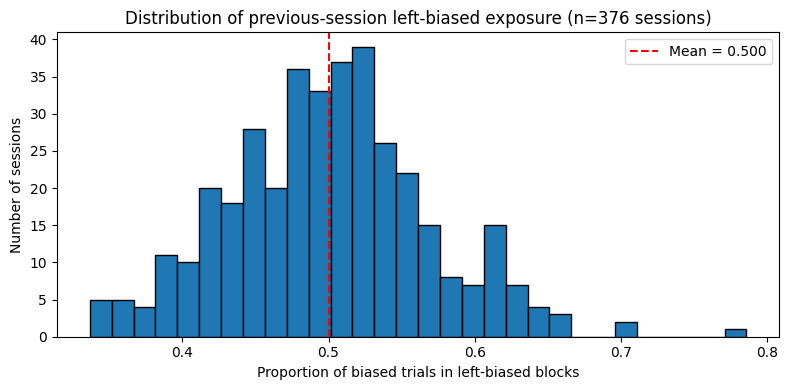

In [88]:
# Left proportion distribution across sessions

plt.figure(figsize=(8, 4))
plt.hist(prop['prop_left'], bins=30, edgecolor='black')
plt.axvline(prop['prop_left'].mean(), color='red', linestyle='--',
            label=f'Mean = {prop["prop_left"].mean():.3f}')
plt.xlabel('Proportion of biased trials in left-biased blocks')
plt.ylabel('Number of sessions')
plt.title(f'Distribution of previous-session left-biased exposure (n={len(prop)} sessions)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Remove no-response trials before choice analysis

No-response trials (`choice = 0`) were retained while defining session eligibility, reconstructing block structure, and calculating previous-session biased exposure. Removing them earlier would change trial counts, block lengths, and the trial-weighted exposure measure.

Once these structural variables have been calculated, no-response trials are removed because they do not represent either a left or right choice and therefore cannot be included in the choice analyses.


In [89]:
# Check for no response trials

print(f"No-response trials in n1_pool: {(n1_pool['choice'] == 0).sum()}")
print(f"No-response trials in n_pool:  {(n_pool['choice'] == 0).sum()}")

No-response trials in n1_pool: 1934
No-response trials in n_pool:  1179


In [90]:
# Remove no-response trials

n1_pool = n1_pool[n1_pool['choice'] != 0].copy()
n_pool  = n_pool[n_pool['choice'] != 0].copy()

## 9. Save the processed datasets
The final trial-level pools, session-pair table, previous-session exposure variable, and session-level summary are saved as Parquet files for use in the subsequent analysis notebooks.

In [91]:
# Save the processed datasets and summary tables

n1_pool.to_parquet('n1_pool.pqt')
n_pool.to_parquet('n_pool.pqt')
pair_table.to_parquet('pair_table.pqt')
prop.to_parquet('prop.pqt')
n_summary.to_parquet('n_summary.pqt')